In [1]:
import requests
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [2]:
url = "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json"

response =  requests.get(url)

response.status_code

200

In [10]:
# the dates this dataset give is from June 14 to June 21 2026 later when You use this notebook for EDA 
# and all the dates will be A week back from current date

In [3]:
data = response.json()
type(data)

list

In [4]:
len(data)

59

In [6]:
# why just 59?
# Because Kp is reported every 3 hours

In [5]:
data[:5]

[{'time_tag': '2026-06-14T00:00:00',
  'Kp': 2.33,
  'a_running': 9,
  'station_count': 7},
 {'time_tag': '2026-06-14T03:00:00',
  'Kp': 2.0,
  'a_running': 7,
  'station_count': 7},
 {'time_tag': '2026-06-14T06:00:00',
  'Kp': 1.33,
  'a_running': 5,
  'station_count': 7},
 {'time_tag': '2026-06-14T09:00:00',
  'Kp': 2.0,
  'a_running': 7,
  'station_count': 7},
 {'time_tag': '2026-06-14T12:00:00',
  'Kp': 1.67,
  'a_running': 6,
  'station_count': 7}]

In [7]:
df = pd.DataFrame(data)

df.head()

,time_tag,Kp,a_running,station_count
0,2026-06-14T00:00:00,2.33,9,7
1,2026-06-14T03:00:00,2.00,7,7
2,2026-06-14T06:00:00,1.33,5,7
3,2026-06-14T09:00:00,2.00,7,7
4,2026-06-14T12:00:00,1.67,6,7


| Kp | Meaning        |
| -- | -------------- |
| 0  | Very Quiet     |
| 1  | Quiet          |
| 2  | Quiet          |
| 3  | Unsettled      |
| 4  | Active         |
| 5  | Minor Storm    |
| 6  | Moderate Storm |
| 7  | Strong Storm   |
| 8  | Severe Storm   |
| 9  | Extreme Storm  |


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time_tag       59 non-null     datetime64[us]
 1   Kp             59 non-null     float64       
 2   a_running      59 non-null     int64         
 3   station_count  59 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 2.0 KB


In [11]:
df.describe()

,Kp,a_running,station_count
count,59.000000,59.000000,59.000000
mean,1.627119,6.169492,7.745763
std,0.553936,2.305560,0.439169
min,0.330000,2.000000,7.000000
25%,1.330000,5.000000,7.500000
50%,1.670000,6.000000,8.000000
75%,2.000000,7.000000,8.000000
max,3.000000,15.000000,8.000000


In [12]:
df["time_tag"] = pd.to_datetime(df["time_tag"])

In [15]:
df.loc[df["Kp"].idxmax()]

time_tag         2026-06-19 00:00:00
Kp                               3.0
a_running                         15
station_count                      8
Name: 40, dtype: object

In [17]:
df.loc[df["Kp"].idxmin()]

time_tag         2026-06-17 18:00:00
Kp                              0.33
a_running                          2
station_count                      8
Name: 30, dtype: object

In [18]:
# Negative Bz
# ≠
# Guaranteed Storm

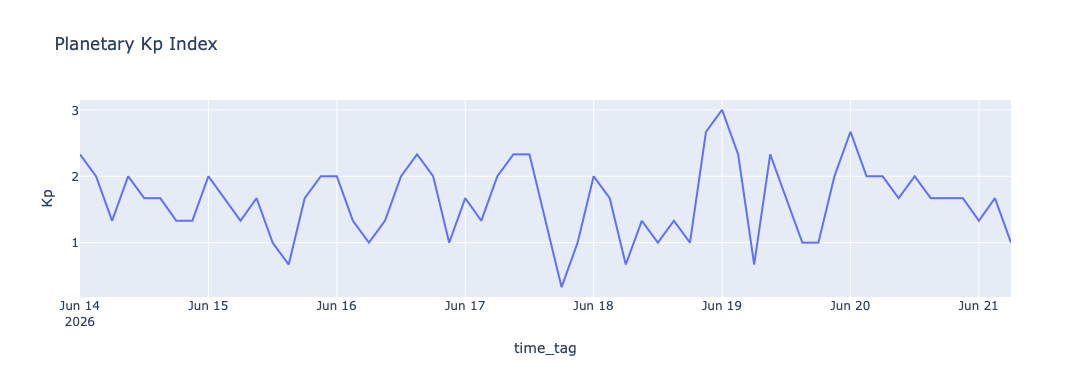

In [19]:
fig = px.line(
    df,
    x="time_tag",
    y="Kp",
    title="Planetary Kp Index"
)

fig

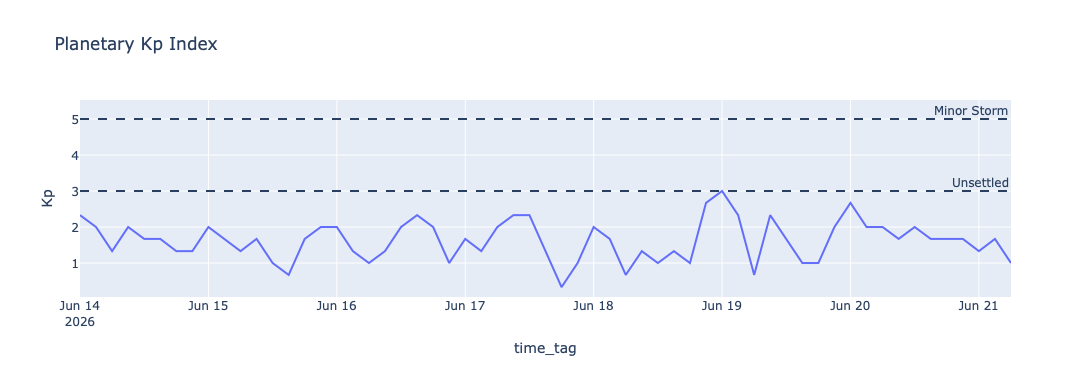

In [20]:
fig = px.line(
    df,
    x="time_tag",
    y="Kp",
    title="Planetary Kp Index"
)

fig.add_hline(y=3,
              line_dash="dash",
              annotation_text="Unsettled")

fig.add_hline(y=5,
              line_dash="dash",
              annotation_text="Minor Storm")

fig

In [21]:
df[df["Kp"] >=2.33]

,time_tag,Kp,a_running,station_count
0,2026-06-14 00:00:00,2.33,9,7
21,2026-06-16 15:00:00,2.33,9,8
27,2026-06-17 09:00:00,2.33,9,8
28,2026-06-17 12:00:00,2.33,9,8
39,2026-06-18 21:00:00,2.67,12,8
40,2026-06-19 00:00:00,3.00,15,8
41,2026-06-19 03:00:00,2.33,9,8
43,2026-06-19 09:00:00,2.33,9,8
48,2026-06-20 00:00:00,2.67,12,8


In [22]:
solar_url = "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"

solar_data = requests.get(solar_url).json()

solar_df = pd.DataFrame(
    solar_data[1:],
    columns=solar_data[0]
)

solar_df.head()

,time_tag,density,speed,temperature
0,2026-06-14 11:24:00.000,9.80,500.2,287313
1,2026-06-14 11:25:00.000,10.55,500.3,219301
2,2026-06-14 11:26:00.000,11.39,499.9,248499
3,2026-06-14 11:27:00.000,11.38,496.9,254035
4,2026-06-14 11:28:00.000,9.50,497.9,209217


In [23]:
imf_url = "https://services.swpc.noaa.gov/products/solar-wind/mag-7-day.json"

imf_data = requests.get(imf_url).json()

imf_df = pd.DataFrame(
    imf_data[1:],
    columns=imf_data[0]
)

imf_df.head()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
0,2026-06-14 11:25:00.000,5.05,-0.59,-1.08,353.34,-12.03,5.20
1,2026-06-14 11:26:00.000,5.04,-0.91,-0.91,349.77,-10.05,5.20
2,2026-06-14 11:27:00.000,5.02,-1.32,-0.75,345.23,-8.26,5.27
3,2026-06-14 11:28:00.000,5.00,-0.89,-1.14,349.86,-12.61,5.25
4,2026-06-14 11:29:00.000,4.96,-1.71,-0.43,340.95,-4.69,5.28


In [24]:
solar_df["time_tag"] = pd.to_datetime(solar_df["time_tag"])

for col in ["density", "speed", "temperature"]:
    solar_df[col] = pd.to_numeric(solar_df[col])

In [25]:
imf_df["time_tag"] = pd.to_datetime(imf_df["time_tag"])

for col in [
    "bx_gsm",
    "by_gsm",
    "bz_gsm",
    "bt",
    "lon_gsm",
    "lat_gsm"
]:
    imf_df[col] = pd.to_numeric(imf_df[col])

In [26]:
kp_df = df.copy()

In [27]:
sw_imf = pd.merge(
    solar_df,
    imf_df,
    on="time_tag",
    how="inner"
)

In [28]:
sw_imf.shape

(9622, 10)

In [29]:
sw_imf["kp_time"] = sw_imf["time_tag"].dt.floor("3h")

In [30]:
sw_imf_3h = (
    sw_imf
    .groupby("kp_time")
    .agg({
        "density": "mean",
        "speed": "mean",
        "temperature": "mean",
        "bz_gsm": "mean",
        "bt": "mean"
    })
    .reset_index()
)

In [31]:
sw_imf_3h.rename(
    columns={"kp_time": "time_tag"},
    inplace=True
)

In [32]:
kp_merged = pd.merge(
    kp_df,
    sw_imf_3h,
    on="time_tag",
    how="inner"
)

In [33]:
kp_merged.head()

,time_tag,Kp,a_running,station_count,density,speed,temperature,bz_gsm,bt
0,2026-06-14 09:00:00,2.00,7,7,9.198000,499.022857,228482.800000,-0.804000,5.214571
1,2026-06-14 12:00:00,1.67,6,7,9.045611,498.691667,205049.672222,0.109778,5.136333
2,2026-06-14 15:00:00,1.67,6,7,8.472778,482.062222,194351.511111,0.800000,4.709556
3,2026-06-14 18:00:00,1.33,5,7,7.728278,472.023889,190409.822222,1.150611,4.305500
4,2026-06-14 21:00:00,1.33,5,7,7.827944,467.417222,187659.683333,0.174722,4.738444


In [34]:
kp_merged.corr(numeric_only=True)

,Kp,a_running,station_count,density,speed,temperature,bz_gsm,bt
Kp,1.000000,0.954030,0.185941,0.160827,-0.107276,-0.017280,-0.188034,0.189507
a_running,0.954030,1.000000,0.198046,0.153802,-0.176655,-0.074964,-0.235377,0.169776
station_count,0.185941,0.198046,1.000000,-0.303894,-0.196446,-0.192283,0.217078,0.446553
density,0.160827,0.153802,-0.303894,1.000000,0.009218,-0.100116,0.324715,0.176347
speed,-0.107276,-0.176655,-0.196446,0.009218,1.000000,0.904124,0.003858,-0.372116
temperature,-0.017280,-0.074964,-0.192283,-0.100116,0.904124,1.000000,-0.280555,-0.352923
bz_gsm,-0.188034,-0.235377,0.217078,0.324715,0.003858,-0.280555,1.000000,0.303532
bt,0.189507,0.169776,0.446553,0.176347,-0.372116,-0.352923,0.303532,1.000000


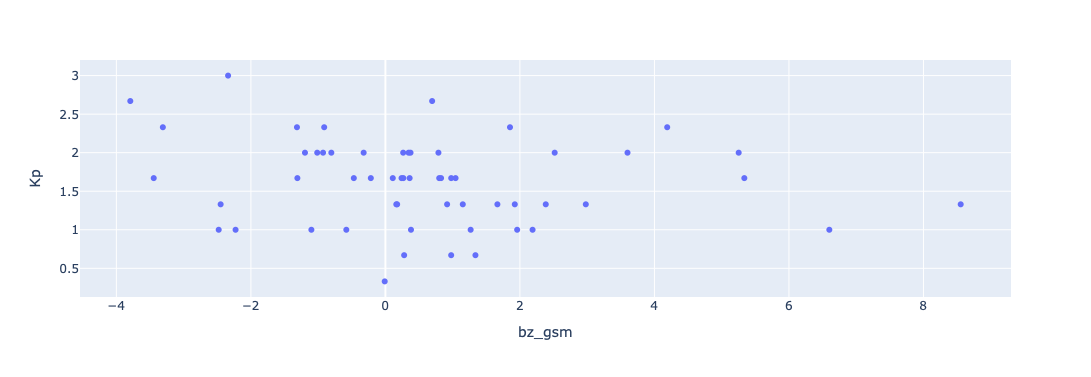

In [35]:
px.scatter(
    kp_merged,
    x="bz_gsm",
    y="Kp"
)

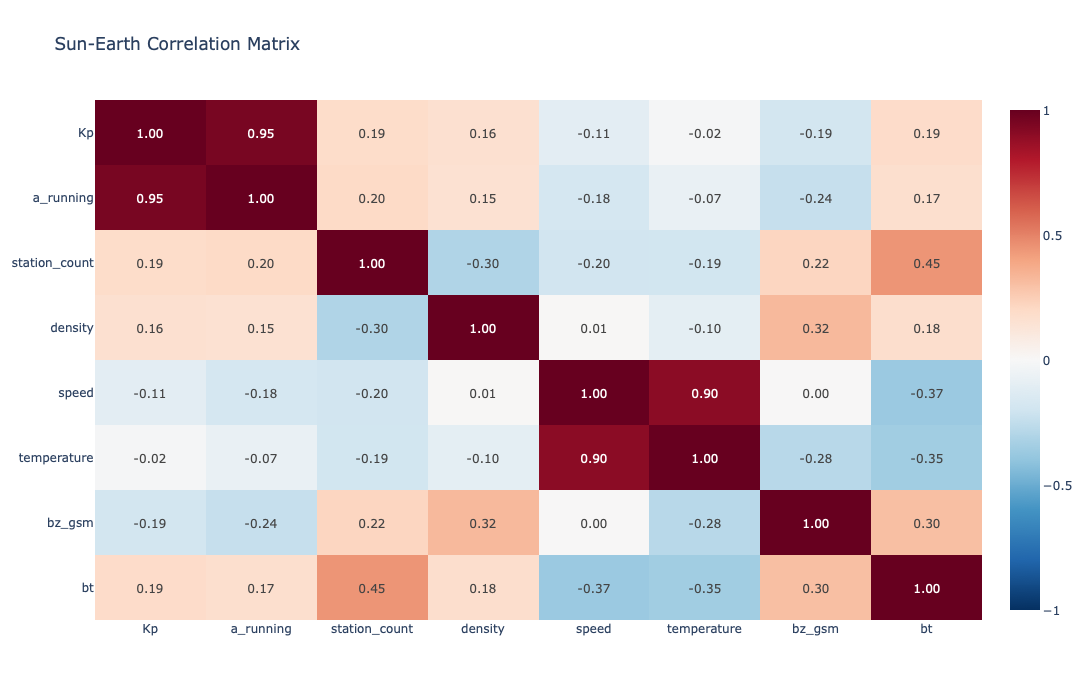

In [37]:


corr_matrix = kp_merged.corr(numeric_only=True)

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Sun-Earth Correlation Matrix"
)

fig.update_layout(
    width=900,
    height=700
)

fig.show()